# 01 — Data Exploration: Tox21 & LD50

Quick look at the downloaded datasets before feature engineering.

**Run `python src/data_download.py` first** to populate `data/processed/`.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/processed")

## 1. Load Tox21

In [15]:
tox21 = pd.read_csv(DATA / "tox21_clean.csv")
print(f"Shape: {tox21.shape}")
tox21.head()

Shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


## 2. Assay label distribution

Check for class imbalance across the 12 assays. Most compounds are inactive (0), so we expect heavy class imbalance.

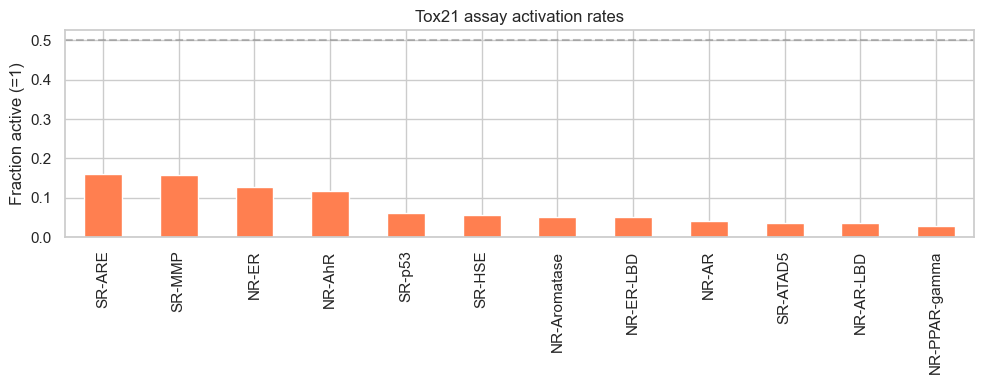


Missing-value % per assay:
NR-AR             7.2
NR-AR-LBD        13.7
NR-AhR           16.4
NR-Aromatase     25.7
NR-ER            20.9
NR-ER-LBD        11.2
NR-PPAR-gamma    17.6
SR-ARE           25.5
SR-ATAD5          9.7
SR-HSE           17.4
SR-MMP           25.8
SR-p53           13.5
dtype: float64


In [16]:
ASSAYS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]
present = [c for c in ASSAYS if c in tox21.columns]

fig, ax = plt.subplots(figsize=(10, 4))
active_rates = tox21[present].mean().sort_values(ascending=False)
active_rates.plot.bar(ax=ax, color="coral")
ax.set_ylabel("Fraction active (=1)")
ax.set_title("Tox21 assay activation rates")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nMissing-value % per assay:")
print((tox21[present].isna().mean() * 100).round(1))

## 3. LD50 labels (if available)

If you've placed `catmos_ld50.csv` in `data/raw/` and re-run the download script, the processed file will be available here.

Shape: (10189, 4)

Toxic label distribution:
toxic
1    6430
0    3759
Name: count, dtype: int64


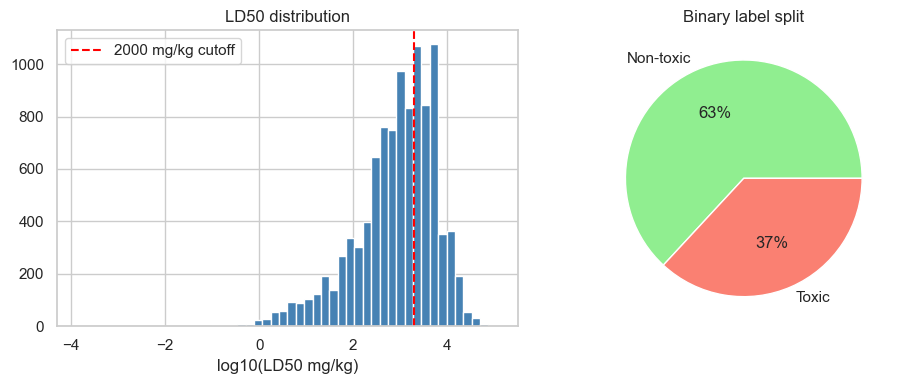

In [17]:
ld50_path = DATA / "ld50_labels.csv"
if ld50_path.exists():
    ld50 = pd.read_csv(ld50_path)
    print(f"Shape: {ld50.shape}")
    print(f"\nToxic label distribution:\n{ld50['toxic'].value_counts()}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ld50["ld50_mgkg"].apply(np.log10).hist(bins=50, ax=axes[0], color="steelblue")
    axes[0].set_xlabel("log10(LD50 mg/kg)")
    axes[0].set_title("LD50 distribution")
    axes[0].axvline(np.log10(2000), color="red", ls="--", label="2000 mg/kg cutoff")
    axes[0].legend()

    ld50["toxic"].value_counts().plot.pie(ax=axes[1], autopct="%1.0f%%",
                                          labels=["Non-toxic", "Toxic"],
                                          colors=["lightgreen", "salmon"])
    axes[1].set_ylabel("")
    axes[1].set_title("Binary label split")
    plt.tight_layout()
    plt.show()
else:
    print("LD50 file not yet available. See data/README.md for download instructions.")

## 4. SMILES sanity check

Verify that all SMILES parse with RDKit.

In [18]:
from rdkit import Chem

valid = tox21["smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None)
print(f"Valid SMILES: {valid.sum()} / {len(valid)}  ({valid.mean()*100:.1f}%)")

if (~valid).any():
    print("\nInvalid SMILES samples:")
    print(tox21.loc[~valid, "smiles"].head(10))

[15:47:26] WARNING: not removing hydrogen atom without neighbors
[15:47:26] Explicit valence for atom # 8 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 3 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 9 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 5 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 16 Al, 6, is greater than permitted
[15:47:26] Explicit valence for atom # 20 Al, 6, is greater than permitted


Valid SMILES: 7823 / 7831  (99.9%)

Invalid SMILES samples:
1322                       NC(=O)NC1N=C(O[AlH3](O)O)NC1=O
2290                                 O=CO[AlH3](OC=O)OC=O
2297                                    CC(=O)O[AlH3](O)O
3558                              CC(=O)O[AlH3](O)OC(C)=O
4565              CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC
4649                              CCCCO[AlH3](OCCCC)OCCCC
5538    O=S(=O)(OC[C@H]1O[C@H](O[C@]2(COS(=O)(=O)O[AlH...
6723                    CCCCCCCCCCCCCCCCCC(=O)O[AlH3](O)O
Name: smiles, dtype: object


## Next steps

1. Run `python src/feature_pipeline.py` to generate Morgan fingerprints + scaffold splits
2. Open `02_baseline_model.ipynb` (to be created) for structure-only baseline
3. Open `03_digital_twin_model.ipynb` for structure + assay model comparison